In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy.stats import bootstrap
from numba import njit
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV, LeaveOneOut
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from scipy.spatial.distance import jensenshannon


ds = np.loadtxt('sdss_cutout.csv', skiprows=1, delimiter=',')

In [2]:
ds1 = np.array([ds[0,:]]) #cutting the dataset
for n in range(1, np.shape(ds)[0]):
    if (ds[n,2] < 0.12 and ds[n,2] > 0.08):
        ds1 = np.append(ds1, np.array([ds[n,:]]), axis = 0)

In [3]:
ds_cut = np.array([ds[0,:]]) #cutting the dataset
for n in range(1, np.shape(ds)[0]):
    if (ds[n,2] < 0.11 and ds[n,2] > 0.09): # I chose 0.09 < z < 0.11
        ds_cut = np.append(ds_cut, np.array([ds[n,:]]), axis = 0)

In [4]:
redgalaxies  = []
bluegalaxies = []

for n in range(np.shape(ds_cut)[0]):
    if (ds_cut[n, 3] - ds_cut[n, 5] > 2.3):
        redgalaxies.append(ds_cut[n, :])
    else:
        bluegalaxies.append(ds_cut[n, :])

redgalaxies  = np.array(redgalaxies)
bluegalaxies = np.array(bluegalaxies)

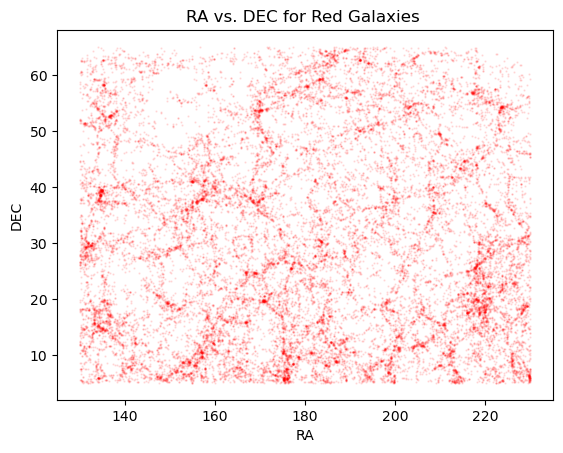

In [5]:
# title und achsenbeschriftungen noch hinzufügen!!!!
plt.scatter(redgalaxies[:,0], redgalaxies[:,1], s=0.5, alpha=0.1, color = "red")
plt.title("RA vs. DEC for Red Galaxies ")
plt.xlabel("RA")
plt.ylabel("DEC")
plt.savefig("RAvsDECred.png")

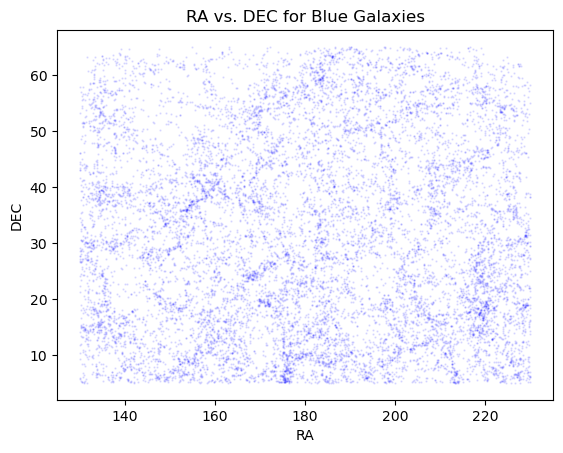

In [6]:
plt.scatter(bluegalaxies[:,0], bluegalaxies[:,1], s=0.5, alpha=0.1, color = "blue")
plt.title("RA vs. DEC for Blue Galaxies")
plt.xlabel("RA")
plt.ylabel("DEC")
plt.savefig("RAvsDECblue.png")

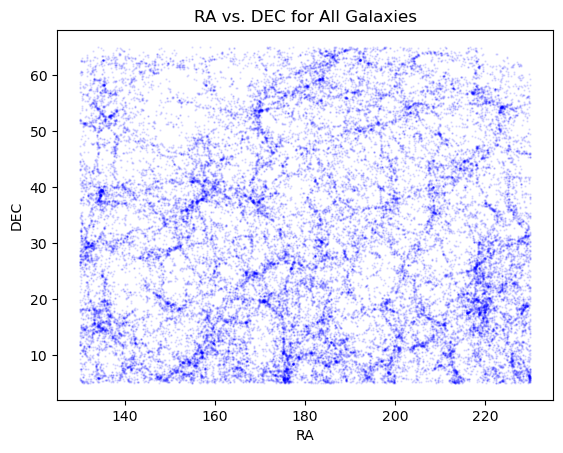

In [7]:
plt.scatter(ds_cut[:,0], ds_cut[:,1], s=0.5, alpha=0.1, color = "blue")
plt.title("RA vs. DEC for All Galaxies")
plt.xlabel("RA")
plt.ylabel("DEC")
plt.savefig("RAvsDECblue.png")

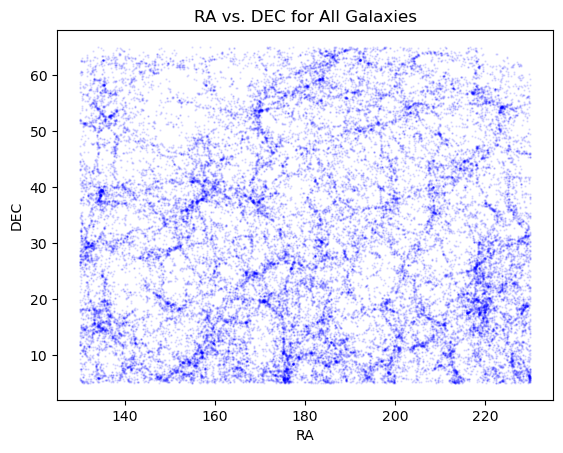

In [8]:
plt.scatter(ds_cut[:,0], ds_cut[:,1], s=0.5, alpha=0.1, color = "blue")
plt.title("RA vs. DEC for All Galaxies")
plt.xlabel("RA")
plt.ylabel("DEC")
plt.savefig("RAvsDECblue.png")

In [9]:
bandwidths = np.geomspace(0.05, 2.0, 30)
grid = GridSearchCV(KernelDensity(kernel='gaussian'),
{'bandwidth': bandwidths}, cv=LeaveOneOut())

idx = np.random.choice(len(ds_cut), 10000, replace=False)
Xdata = ds_cut[idx]
Xdata = Xdata[:,0:2]


In [10]:
grid.fit(Xdata) # Xdata has shape (N,2) for 2D
h_opt = grid.best_params_['bandwidth']

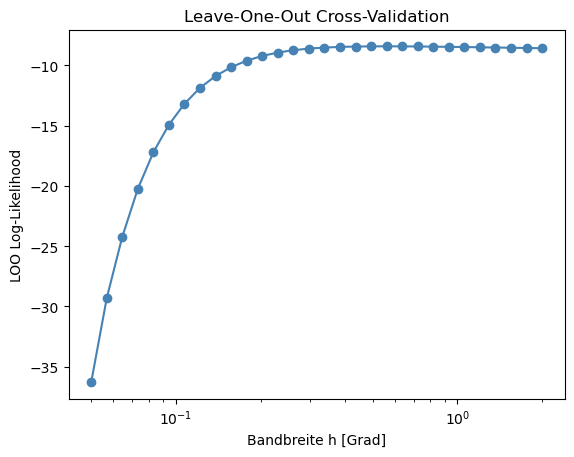

In [11]:
lloo = grid.cv_results_['mean_test_score'] 

# Plot
plt.plot(bandwidths, lloo, 'o-', color='steelblue')
plt.xlabel('Bandbreite h [Grad]')
plt.ylabel('LOO Log-Likelihood')
plt.title('Leave-One-Out Cross-Validation')
plt.xscale('log')  
plt.savefig("LOOCV.png")
plt.show()

In [12]:
h_opt

np.float64(0.5605256821712369)

In [13]:
bandwidths = np.geomspace(0.05, 2.0, 30)

In [14]:


std = np.sqrt((np.std(Xdata[:,0]) * np.std(Xdata[:,1])))
std

h_silv = std * len(Xdata)**(-1/6)

In [15]:
print( "Silverman's Rule using geometric mean of marginal std: ", h_silv)
print( "h_opt: ", h_opt)

Silverman's Rule using geometric mean of marginal std:  4.7778319883199725
h_opt:  0.5605256821712369


In [16]:
ra_grid  = np.linspace(130,  230,  200)
dec_grid = np.linspace(5, 65, 200)

RA_grid, DEC_grid = np.meshgrid(ra_grid, dec_grid)
grid_points = np.column_stack([RA_grid.ravel(), DEC_grid.ravel()])  # shape (200*200, 2)

In [17]:
kde_undersmoothed = KernelDensity(kernel='gaussian', bandwidth=bandwidths[0])
kde_undersmoothed.fit(Xdata)
log_dens_under = kde_undersmoothed.score_samples(grid_points)  # grid_points shape (M, 2)
density_undersmoothed  = np.exp(log_dens_under).reshape(200, 200)      # zurück in 2D-Form

In [18]:
kde_opt = KernelDensity(kernel='gaussian', bandwidth=h_opt)
kde_opt.fit(Xdata)
log_dens_opt = kde_opt.score_samples(grid_points)
density_opt = np.exp(log_dens_opt).reshape(200, 200)

kde_oversmoothed = KernelDensity(kernel='gaussian', bandwidth=bandwidths[-1])
kde_oversmoothed.fit(Xdata)
log_dens_oversmoothed = kde_oversmoothed.score_samples(grid_points)
density_over = np.exp(log_dens_oversmoothed).reshape(200, 200)

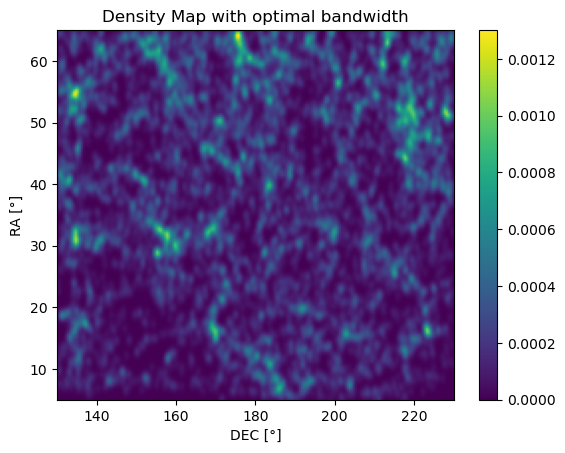

In [19]:
plt.imshow(density_opt,  extent=[130, 230, 5, 65], aspect = "auto")
plt.title("Density Map with optimal bandwidth")
plt.xlabel("DEC [°]")
plt.ylabel("RA [°]")
plt.colorbar()
plt.savefig("density_opt.png")

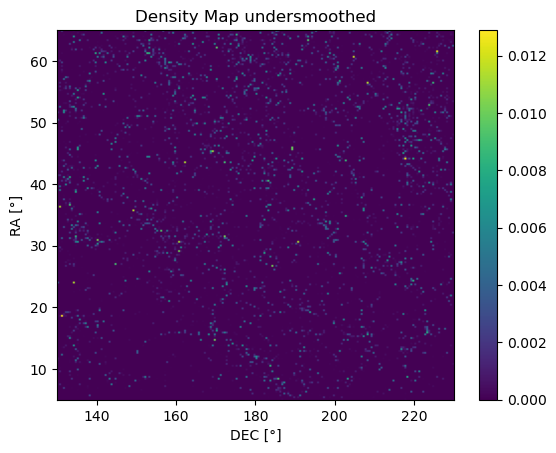

In [20]:
plt.imshow(density_undersmoothed,  extent=[130, 230, 5, 65], aspect = "auto")
plt.title("Density Map undersmoothed")
plt.xlabel("DEC [°]")
plt.ylabel("RA [°]")
plt.colorbar()
plt.savefig("density_undersmoothed.png")

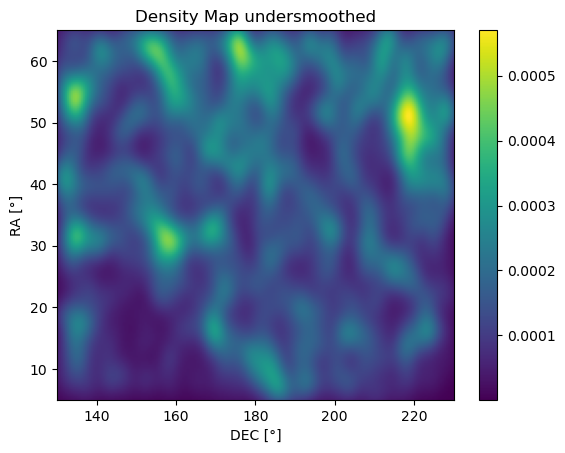

In [21]:
plt.imshow(density_over,  extent=[130, 230, 5, 65], aspect = "auto")
plt.title("Density Map undersmoothed")
plt.xlabel("DEC [°]")
plt.ylabel("RA [°]")
plt.colorbar()
plt.savefig("density_oversmoothed.png")

In [22]:
X_train, X_test = train_test_split(ds_cut, test_size=0.25, random_state=42)

X_train = (X_train[:,3] - X_train[:,5]).reshape(-1,1)
X_test = (X_test[:,3] - X_test[:,5]).reshape(-1,1)

In [23]:
bic = np.zeros(6,)
for N_cluster in np.arange(1,7):
    GM = GaussianMixture( n_components  = N_cluster, n_init = 20, random_state = 42 )
    GMmodel = GM.fit( X_train )
    GMM_dens_at_x = np.exp( GMmodel.score_samples( X_test ) )
    bic[N_cluster -1 ] = GMmodel.bic(X_train)

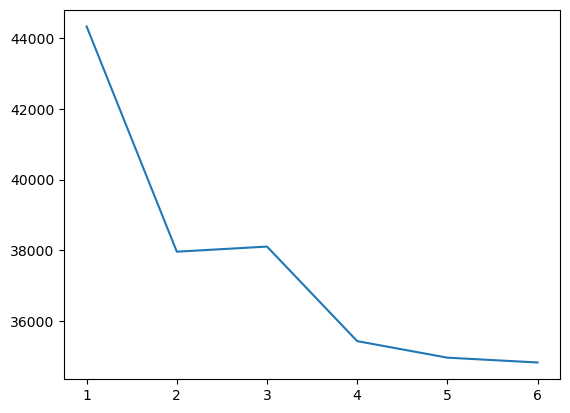

In [24]:
plt.plot(np.arange(1,7), bic)

In [25]:
delta_bic = (bic[0:5] - bic[1:6])
print(delta_bic)

[6371.32895806 -145.18954255 2674.80563306  468.08368644  135.93818145]


In [26]:
GM_chosen = GaussianMixture( n_components  = 3, n_init = 20, random_state = 42 )
GMmodel_chosen = GM_chosen.fit(X_train)
tau = GMmodel_chosen.predict_proba(X_train)

Text(0, 0.5, '$t_i(X_i)$')

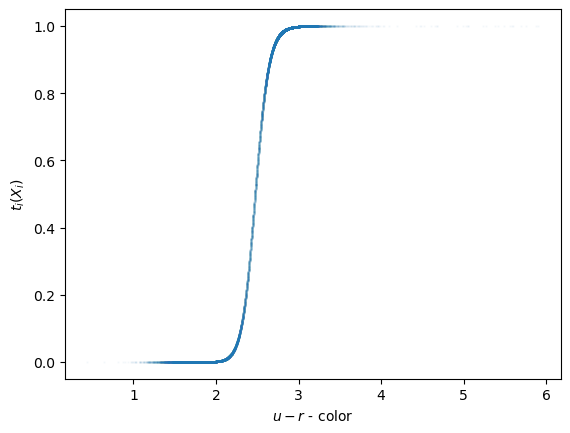

In [27]:
plt.scatter(X_train, tau[:,0], s=0.5, alpha=0.03)
plt.xlabel("$u-r$ - color")
plt.ylabel("$t_i(X_i)$")


In [36]:
# create a kernel density estimator object
kde_task4 = KernelDensity(kernel='gaussian', bandwidth=h_opt)
# create a model by 'fitting' the KDE to our data (no actual fitting)
model_task4 = kde_task4.fit( ds_cut[:, 0:2])

In [46]:
rho = np.exp(kde_task4.score_samples(ds_cut[:, 0:2]))
q25 = np.percentile(rho, 25)
q75 = np.percentile(rho, 75)

colors = ds_cut[:,3]-ds_cut[:,5]

colors_low = (colors[rho < q25]).reshape(-1,1)
colors_high = (colors[rho > q75]).reshape(-1,1)

In [47]:
def silverman(x):
    #returns silvemrans rule for 1D Array
    return 1.06 * np.std(x) * len(x)**(-1/5)

kde_low = KernelDensity(kernel='gaussian', bandwidth= silverman(colors_low))
model_low = kde_low.fit(colors_low)

kde_high = KernelDensity(kernel = "gaussian", bandwidth = silverman(colors_high))
model_high = kde_high.fit(colors_high)



In [48]:
c_min = np.min(ds_cut[:,3]-ds_cut[:,5])
c_max = np.max(ds_cut[:,3]-ds_cut[:,5])

In [49]:
cgrid = np.linspace(c_min, c_max, 500)

p_low = np.exp(kde_low.score_samples(cgrid[:,np.newaxis]))
p_high = np.exp(kde_high.score_samples(cgrid[:,np.newaxis]))
dc = cgrid[1]-cgrid[0]
p_low /= p_low.sum()*dc; p_high /= p_high.sum()*dc
D_JS = jensenshannon(p_low, p_high)**2 

In [50]:
D_JS

np.float64(0.01607043379328784)